#### Assignmnet 8 - Hybrid Workflow


In [139]:
!pip install langgraph langchain langchain-google-genai serpapi

In [140]:
import os
from typing import TypedDict, Literal, Annotated
import operator
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import serpapi

os.environ["GOOGLE_API_KEY"] = "GOOGLE-API-KEY"
os.environ["SERPAPI_API_KEY"] = "SERPAPI-KEY"

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)

#### Scenario - Telecom

In [141]:
class TelecomState(TypedDict):
    complaint: str
    customer_name: str
    issue_type: str
    severity: str
    backend_result: str
    routed_team: str
    # final_resolution: str

    customer_response: str
    technician_notes: str
    estimated_resolution_time: str
    final_summary: str

In [142]:
def complaint_understanding(state):
    return {
        "complaint": state["complaint"],
        "customer_name": state["customer_name"]
    }

In [143]:
def extract_issue_type(state):
    complaint = state["complaint"]

    prompt = f"""
    Identify only the telecom issue type from this complaint:

    {complaint}

    Example outputs:
    Tower Outage
    Billing Issue
    SIM Problem
    Slow Internet
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "issue_type": response
    }

In [144]:
def detect_severity(state):
    complaint = state["complaint"]

    prompt = f"""
    Detect severity of this telecom complaint:

    {complaint}

    Return only one word:
    Low
    Medium
    High
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "severity": response
    }

In [145]:
def backend_check(state):
    issue = state["issue_type"].lower()

    if "billing" in issue:
        result = "Billing mismatch found"

    elif "signal" in issue or "outage" in issue:
        result = "Tower outage detected"

    elif "sim" in issue:
        result = "SIM issue detected"

    else:
        result = "Network congestion found"

    return {
        "backend_result": result
    }

In [146]:
def route_issue(state):
    backend = state["backend_result"]

    if "Billing" in backend:
        team = "Billing Team"

    elif "Tower outage" in backend:
        team = "Network Operations"

    elif "SIM" in backend:
        team = "Device Support"

    else:
        team = "Support Team"

    return {
        "routed_team": team
    }

In [147]:
def display_result(result):
    print("\n--- Telecom Resolution ---")
    print(f"Customer : {result['customer_name']}")
    print(f"Issue    : {result['issue_type']}")
    print(f"Severity : {result['severity']}")
    print(f"Team     : {result['routed_team']}")
    print(f"Status   : {result['final_resolution']}")

In [149]:
def resolution_agent(state):
    prompt = f"""
You are a telecom incident resolution AI assistant.

Complaint: {state['complaint']}
Issue Type: {state['issue_type']}
Severity: {state['severity']}
Backend Finding: {state['backend_result']}
Assigned Team: {state['routed_team']}

Generate all of the following. Respond strictly in this format:

CUSTOMER_RESPONSE: <Polite professional message to customer>
TECHNICIAN_NOTES: <Internal notes for technician/support team>
ESTIMATED_RESOLUTION_TIME: <Example: 2 hours, 24 hours>
FINAL_SUMMARY: <One-line summary of issue and resolution>
"""

    response = llm.invoke(prompt)
    lines = response.content.strip().split("\n")

    customer_response = ""
    technician_notes = ""
    estimated_resolution_time = ""
    final_summary = ""

    for line in lines:
        if line.startswith("CUSTOMER_RESPONSE:"):
            customer_response = line.replace("CUSTOMER_RESPONSE:", "").strip()

        elif line.startswith("TECHNICAN_NOTES:"):
            technician_notes = line.replace("TECHNICAN_NOTES:", "").strip()

        elif line.startswith("TECHNICIAN_NOTES:"):
            technician_notes = line.replace("TECHNICIAN_NOTES:", "").strip()

        elif line.startswith("ESTIMATED_RESOLUTION_TIME:"):
            estimated_resolution_time = line.replace("ESTIMATED_RESOLUTION_TIME:", "").strip()

        elif line.startswith("FINAL_SUMMARY:"):
            final_summary = line.replace("FINAL_SUMMARY:", "").strip()

    return {
        "customer_response": customer_response,
        "technician_notes": technician_notes,
        "estimated_resolution_time": estimated_resolution_time,
        "final_summary": final_summary
    }

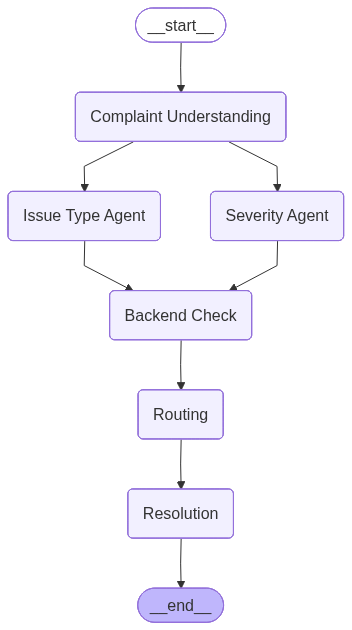

In [150]:
builder = StateGraph(TelecomState)

builder.add_node("Complaint Understanding", complaint_understanding)
builder.add_node("Issue Type Agent", extract_issue_type)
builder.add_node("Severity Agent", detect_severity)
builder.add_node("Backend Check", backend_check)
builder.add_node("Routing", route_issue)
builder.add_node("Resolution", resolution_agent)

builder.set_entry_point("Complaint Understanding")

# Parallel execution
builder.add_edge("Complaint Understanding", "Issue Type Agent")
builder.add_edge("Complaint Understanding", "Severity Agent")

# Merge
builder.add_edge("Issue Type Agent", "Backend Check")
builder.add_edge("Severity Agent", "Backend Check")

# Continue flow
builder.add_edge("Backend Check", "Routing")
builder.add_edge("Routing", "Resolution")
builder.add_edge("Resolution", END)

graph = builder.compile()
graph

In [151]:
def display_result(result):
    print("\n--- Telecom Resolution ---")

    print(f"Customer   : {result['customer_name']}")
    print(f"Issue      : {result['issue_type']}")
    print(f"Severity   : {result['severity']}")
    print(f"Team       : {result['routed_team']}")

    print("\nCustomer Response:")
    print(result["customer_response"])

    print("\nTechnician Notes:")
    print(result["technician_notes"])

    print("\nEstimated Resolution Time:")
    print(result["estimated_resolution_time"])

    print("\nFinal Summary:")
    print(result["final_summary"])

In [152]:
result = graph.invoke({
    "complaint": "Entire area has no signal since morning",
    "customer_name": "Rahul Menon"
})

display_result(result)


--- Telecom Resolution ---
Customer   : Rahul Menon
Issue      : Tower Outage
Severity   : High
Team       : Network Operations

Customer Response:
Dear customer, we apologize for the inconvenience. We have detected a tower outage affecting your area, which is causing the signal loss you're experiencing. Our Network Operations team is actively working to restore service as quickly as possible. We estimate the issue will be resolved within 24 hours. Thank you for your patience.

Technician Notes:
High severity tower outage detected affecting an entire area, resulting in no signal for customers. Backend systems confirm tower is down. Network Operations team has been assigned to investigate the root cause and restore service. Priority: Urgent.

Estimated Resolution Time:
Within 24 hours

Final Summary:
Area-wide signal loss due to high severity tower outage; Network Operations team is actively working on restoration.


In [153]:
result = graph.invoke({
    "complaint": "My SIM stopped working after recharge and I cannot make calls",
    "customer_name": "Arjun Thomas"
})

display_result(result)


--- Telecom Resolution ---
Customer   : Arjun Thomas
Issue      : SIM Problem
Severity   : Medium
Team       : Device Support

Customer Response:
Dear customer, we apologize for the inconvenience you're experiencing with your SIM not working after your recent recharge. We've identified a SIM-related issue and our Device Support team is actively working on resolving it. We estimate your service will be restored within 24 hours. We will keep you updated on the progress.

Technician Notes:
Customer reported SIM stopped working and unable to make calls after a recent recharge. Backend findings confirm a SIM issue. Device Support team to investigate SIM provisioning status, network registration, and potential activation errors. Verify successful recharge application. Action required: Diagnose and resolve backend SIM issue; if necessary, guide customer through SIM refresh or replacement process.

Estimated Resolution Time:
24 hours

Final Summary:
Customer's SIM stopped working post-recharg

#### Scenario - Healthcare

In [154]:
class HealthcareState(TypedDict):
    symptoms: str
    patient_name: str
    symptom_type: str
    severity: str
    medical_guidance: str
    routed_department: str
    # final_response: str

    triage_summary: str
    specialist: str
    follow_up: str
    diagnostic_tests: str
    emergency_alert: str

In [155]:
def symptom_understanding(state):
    return {
        "symptoms": state["symptoms"],
        "patient_name": state["patient_name"]
    }

In [156]:
def extract_symptom_type(state):
    prompt = f"""
    Identify the medical symptom type from:

    {state['symptoms']}

    Example outputs:
    Cardiac Issue
    Fever
    Skin Allergy
    Neurological Issue
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "symptom_type": response
    }

In [157]:
def detect_severity(state):
    prompt = f"""
    Detect severity of this medical case:

    {state['symptoms']}

    Return only:
    Low
    Medium
    High
    Emergency
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "severity": response
    }

In [158]:
def knowledge_retrieval(state):
    symptom = state["symptom_type"]

    params = {
        "engine": "google",
        "q": f"medical guidance for {symptom}",
        "api_key": os.environ["SERPAPI_API_KEY"]
    }

    try:
        search = serpapi.GoogleSearch(params)
        results = search.get_dict()

        guidance = f"Medical guidance retrieved for {symptom}"

    except Exception:
        guidance = "Basic medical guidance generated"

    return {
        "medical_guidance": guidance
    }

In [159]:
def route_case(state):
    symptom = state["symptom_type"].lower()
    severity = state["severity"].lower()

    if "cardiac" in symptom or severity == "emergency":
        dept = "Emergency Department"

    elif "neurological" in symptom:
        dept = "Neurology"

    elif "allergy" in symptom:
        dept = "Pharmacy Review"

    else:
        dept = "General Physician"

    return {
        "routed_department": dept
    }

In [160]:
def care_coordination(state):
    prompt = f"""
You are a clinical triage assistant.

Symptoms: {state['symptoms']}
Condition: {state['symptom_type']}
Severity: {state['severity']}
Department: {state['routed_department']}
Medical Guidance: {state['medical_guidance']}

Generate all of the following. Respond strictly in this format:

TRIAGE_SUMMARY: <Short summary of patient condition>
SPECIALIST: <Recommended specialist>
FOLLOW_UP: <Follow-up instructions for patient>
DIAGNOSTIC_TESTS: <Recommended tests>
EMERGENCY_ALERT: <Yes/No + short reason>
"""

    response = llm.invoke(prompt)
    lines = response.content.strip().split("\n")

    triage_summary = ""
    specialist = ""
    follow_up = ""
    diagnostic_tests = ""
    emergency_alert = ""

    for line in lines:
        if line.startswith("TRIAGE_SUMMARY:"):
            triage_summary = line.replace("TRIAGE_SUMMARY:", "").strip()

        elif line.startswith("SPECIALIST:"):
            specialist = line.replace("SPECIALIST:", "").strip()

        elif line.startswith("FOLLOW_UP:"):
            follow_up = line.replace("FOLLOW_UP:", "").strip()

        elif line.startswith("DIAGNOSTIC_TESTS:"):
            diagnostic_tests = line.replace("DIAGNOSTIC_TESTS:", "").strip()

        elif line.startswith("EMERGENCY_ALERT:"):
            emergency_alert = line.replace("EMERGENCY_ALERT:", "").strip()

    return {
        "triage_summary": triage_summary,
        "specialist": specialist,
        "follow_up": follow_up,
        "diagnostic_tests": diagnostic_tests,
        "emergency_alert": emergency_alert
    }

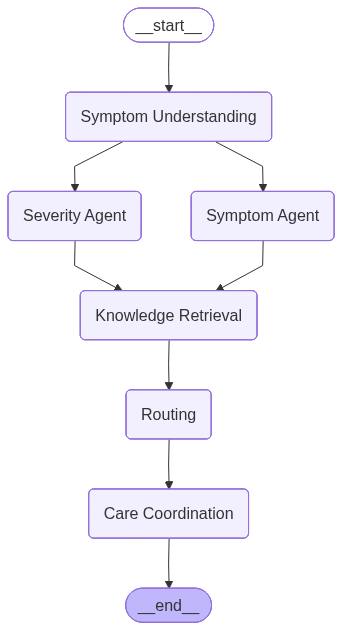

In [161]:
builder = StateGraph(HealthcareState)

builder.add_node("Symptom Understanding", symptom_understanding)
builder.add_node("Symptom Agent", extract_symptom_type)
builder.add_node("Severity Agent", detect_severity)
builder.add_node("Knowledge Retrieval", knowledge_retrieval)
builder.add_node("Routing", route_case)
builder.add_node("Care Coordination", care_coordination)

builder.set_entry_point("Symptom Understanding")

# Parallel execution
builder.add_edge("Symptom Understanding", "Symptom Agent")
builder.add_edge("Symptom Understanding", "Severity Agent")

# Merge
builder.add_edge("Symptom Agent", "Knowledge Retrieval")
builder.add_edge("Severity Agent", "Knowledge Retrieval")

# Continue flow
builder.add_edge("Knowledge Retrieval", "Routing")
builder.add_edge("Routing", "Care Coordination")
builder.add_edge("Care Coordination", END)

graph = builder.compile()
graph

In [162]:
def display_result(result):
    print("\n--- Healthcare Triage Result ---")

    print(f"Patient    : {result['patient_name']}")
    print(f"Condition  : {result['symptom_type']}")
    print(f"Severity   : {result['severity']}")
    print(f"Department : {result['routed_department']}")

    print("\nTriage Summary:")
    print(result["triage_summary"])

    print("\nSpecialist:")
    print(result["specialist"])

    print("\nFollow Up:")
    print(result["follow_up"])

    print("\nDiagnostic Tests:")
    print(result["diagnostic_tests"])

    print("\nEmergency Alert:")
    print(result["emergency_alert"])

In [163]:
result = graph.invoke({
    "symptoms": "Chest pain and shortness of breath",
    "patient_name": "Anjali Nair"
})

display_result(result)


--- Healthcare Triage Result ---
Patient    : Anjali Nair
Condition  : Cardiac Issue
Severity   : Emergency
Department : Emergency Department

Triage Summary:
Patient presenting with acute chest pain and shortness of breath, highly suggestive of a cardiac emergency.

Specialist:
Cardiologist (initial assessment by Emergency Physician)

Follow Up:
Immediate transfer to the Emergency Department for urgent medical evaluation and intervention. Do not delay seeking care.

Diagnostic Tests:
Electrocardiogram (ECG), Cardiac Troponins, Chest X-ray, Complete Blood Count (CBC), Basic Metabolic Panel (BMP), Oxygen Saturation, Echocardiogram (as indicated).

Emergency Alert:
Yes, symptoms (chest pain, shortness of breath) are indicative of a potential life-threatening cardiac event requiring immediate medical intervention.


In [164]:
result = graph.invoke({
    "symptoms": "Mild skin rash after taking antibiotics",
    "patient_name": "Sneha Thomas"
})

display_result(result)


--- Healthcare Triage Result ---
Patient    : Sneha Thomas
Condition  : Skin Allergy
Severity   : Low
Department : Pharmacy Review

Triage Summary:
Patient presents with a mild skin rash, likely an allergic reaction, after taking antibiotics.

Specialist:
Pharmacist

Follow Up:
Contact the prescribing doctor or pharmacist for advice regarding the antibiotic. Monitor the rash for any changes or worsening. Avoid self-treating without professional guidance.

Diagnostic Tests:
None immediately indicated.

Emergency Alert:
No, symptoms are currently mild.


#### Scenario - Finance

In [165]:
class FinanceState(TypedDict):
    applicant_details: str
    applicant_name: str
    profile_type: str
    risk_level: str
    verification_result: str
    routed_team: str
    # final_decision: str

    decision_reason: str
    risk_summary: str
    recommended_loan: str
    interest_slab: str
    applicant_notification: str

In [166]:
def applicant_understanding(state):
    return {
        "applicant_details": state["applicant_details"],
        "applicant_name": state["applicant_name"]
    }

In [167]:
def analyze_profile(state):
    prompt = f"""
    Analyze this loan applicant profile:

    {state['applicant_details']}

    Return only:
    Excellent Profile
    Medium Profile
    Weak Profile
    Missing Documents
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "profile_type": response
    }

In [168]:
def detect_risk(state):
    prompt = f"""
    Detect loan approval risk for:

    {state['applicant_details']}

    Return only:
    Low Risk
    Medium Risk
    High Risk
    Fraud Risk
    """

    response = llm.invoke(prompt).content.strip()

    return {
        "risk_level": response
    }

In [169]:
def verification_layer(state):
    profile = state["profile_type"]

    params = {
        "engine": "google",
        "q": f"loan verification check {profile}",
        "api_key": os.environ["SERPAPI_API_KEY"]
    }

    try:
        search = GoogleSearch(params)
        results = search.get_dict()

        verification = f"Verification completed for {profile}"

    except Exception:
        verification = "Basic verification completed"

    return {
        "verification_result": verification
    }

In [170]:
def route_application(state):
    profile = state["profile_type"].lower()
    risk = state["risk_level"].lower()

    if "fraud" in risk:
        team = "Fraud Investigation"

    elif "excellent" in profile and "low" in risk:
        team = "Fast Track Approval"

    elif "missing" in profile:
        team = "Clarification Team"

    elif "high" in risk:
        team = "Manual Review"

    else:
        team = "Standard Approval"

    return {
        "routed_team": team
    }

In [171]:
def final_decision_agent(state):
    prompt = f"""
You are a loan decision AI assistant.

Applicant: {state['applicant_details']}
Profile: {state['profile_type']}
Risk: {state['risk_level']}
Assigned Team: {state['routed_team']}
Verification: {state['verification_result']}

Generate all of the following. Respond strictly in this format:

DECISION_REASON: <Approval/Rejection reason>
RISK_SUMMARY: <Short risk summary>
RECOMMENDED_LOAN: <Suggested loan amount>
INTEREST_SLAB: <Suggested interest slab>
APPLICANT_NOTIFICATION: <Short customer-facing notification>
"""

    response = llm.invoke(prompt)
    lines = response.content.strip().split("\n")

    decision_reason = ""
    risk_summary = ""
    recommended_loan = ""
    interest_slab = ""
    applicant_notification = ""

    for line in lines:
        if line.startswith("DECISION_REASON:"):
            decision_reason = line.replace("DECISION_REASON:", "").strip()

        elif line.startswith("RISK_SUMMARY:"):
            risk_summary = line.replace("RISK_SUMMARY:", "").strip()

        elif line.startswith("RECOMMENDED_LOAN:"):
            recommended_loan = line.replace("RECOMMENDED_LOAN:", "").strip()

        elif line.startswith("INTEREST_SLAB:"):
            interest_slab = line.replace("INTEREST_SLAB:", "").strip()

        elif line.startswith("APPLICANT_NOTIFICATION:"):
            applicant_notification = line.replace("APPLICANT_NOTIFICATION:", "").strip()

    return {
        "decision_reason": decision_reason,
        "risk_summary": risk_summary,
        "recommended_loan": recommended_loan,
        "interest_slab": interest_slab,
        "applicant_notification": applicant_notification
    }

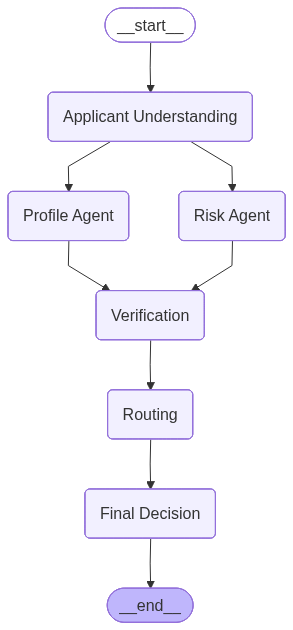

In [172]:
builder = StateGraph(FinanceState)

builder.add_node("Applicant Understanding", applicant_understanding)
builder.add_node("Profile Agent", analyze_profile)
builder.add_node("Risk Agent", detect_risk)
builder.add_node("Verification", verification_layer)
builder.add_node("Routing", route_application)
builder.add_node("Final Decision", final_decision_agent)

builder.set_entry_point("Applicant Understanding")

# Parallel execution
builder.add_edge("Applicant Understanding", "Profile Agent")
builder.add_edge("Applicant Understanding", "Risk Agent")

# Merge
builder.add_edge("Profile Agent", "Verification")
builder.add_edge("Risk Agent", "Verification")

# Continue flow
builder.add_edge("Verification", "Routing")
builder.add_edge("Routing", "Final Decision")
builder.add_edge("Final Decision", END)

graph = builder.compile()
graph

In [173]:
def display_result(result):
    print("\n--- Loan Assessment Result ---")

    print(f"Applicant : {result['applicant_name']}")
    print(f"Profile   : {result['profile_type']}")
    print(f"Risk      : {result['risk_level']}")
    print(f"Team      : {result['routed_team']}")

    print("\nDecision Reason:")
    print(result["decision_reason"])

    print("\nRisk Summary:")
    print(result["risk_summary"])

    print("\nRecommended Loan:")
    print(result["recommended_loan"])

    print("\nInterest Slab:")
    print(result["interest_slab"])

    print("\nApplicant Notification:")
    print(result["applicant_notification"])

In [174]:
result = graph.invoke({
    "applicant_details": "Applicant has stable salary, good credit score, and requests home loan",
    "applicant_name": "Arjun Thomas"
})

display_result(result)


--- Loan Assessment Result ---
Applicant : Arjun Thomas
Profile   : Excellent Profile
Risk      : Low Risk
Team      : Fast Track Approval

Decision Reason:
Approved due to excellent credit profile, stable income, and low risk assessment.

Risk Summary:
Low risk applicant with strong financial stability and excellent credit history.

Recommended Loan:
Up to $650,000

Interest Slab:
3.8% (Tier 1 - Premium Customer Rate)

Applicant Notification:
Congratulations! Your home loan application has been approved. We are pleased to offer you a competitive interest rate. Our Fast Track Approval team will contact you within 24 hours to discuss the next steps.


In [175]:
result = graph.invoke({
    "applicant_details": "Applicant has irregular income, poor credit score, and suspicious transaction history",
    "applicant_name": "Anjali Nair"
})

display_result(result)


--- Loan Assessment Result ---
Applicant : Anjali Nair
Profile   : Weak Profile
Risk      : Fraud Risk
Team      : Fraud Investigation

Decision Reason:
Rejection due to high fraud risk identified from suspicious transaction history, coupled with a weak financial profile characterized by irregular income and a poor credit score. Application requires further investigation by the Fraud Investigation team.

Risk Summary:
High fraud risk due to suspicious transaction history. Significant credit risk due to irregular income and poor credit score. Overall weak applicant profile.

Recommended Loan:
0

Interest Slab:
N/A

Applicant Notification:
Thank you for your application. After careful review, we are unable to approve your loan request at this time as it does not meet our current lending criteria. We appreciate your understanding.
